In [2]:
import numpy as np
import bacco
import matplotlib.pyplot as plt
import bacco.probabilistic_bias as pb

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [3]:
import os
os.chdir('/mnt/ceph/users/fmaion/packages/bias_tools/src/')
import merger_tree_tools as mgt
import plotter as plotter
import cutter as cutter
import saver as saver

In [4]:
def q_pos(mbID, npart=4320, BoxSize=500, mtng=False, idstart=0):

    if mtng:
        mbID[np.where(mbID>=1)] -= 20155392000
        mbID[np.where(mbID<1)] += 80621568000

    q = np.zeros(mbID.shape + (3,), dtype=np.float32)

    q[..., 0] = (mbID - idstart) // npart**2
    q[..., 1] = ( (mbID - idstart) // npart) % npart
    q[..., 2] = (mbID - idstart) % npart

    # normalize correctly
    q *= (BoxSize / npart)

    return q


In [5]:
dir_name = "/mnt/ceph/users/fmaion/projects/THYME/simulations/Nenya_N3072_L1024.0_output/0.00/"

sim = bacco.Simulation(basedir=dir_name, halo_file="groups_054/fof_subhalo_history_tab_orph_wweight_054",\
                       sim_format='gadget_hdf5', fixedPk=True)

2025-12-11 15:33:37,960 bacco.sims : Initialising simulation Default
2025-12-11 15:33:37,961 bacco.sims : try /mnt/ceph/users/fmaion/projects/THYME/simulations/Nenya_N3072_L1024.0_output/0.00/groups_054/fof_subhalo_history_tab_orph_wweight_054
2025-12-11 15:33:38,020 bacco.sims : Loading /mnt/ceph/users/fmaion/projects/THYME/simulations/Nenya_N3072_L1024.0_output/0.00/groups_054/fof_subhalo_history_tab_orph_wweight_054
2025-12-11 15:33:38,039 bacco.sims : ...done in 0.0625 s


In [6]:
# These are the variables that need to be measured on a Lagrangian grid
variables = ("J2", "J2=2", "J4", "J4=4", "J2=4")
terms = ("J2", "J22", "J2=2")


In [7]:
q_halo = q_pos(sim.fof['halo_mbid'], npart=3072, BoxSize=1024, mtng=False, idstart=0)


2025-12-11 15:35:14,864 bacco.sims : Reading 55270900 items for halo_firstsub
2025-12-11 15:35:39,736 bacco.sims : Reading 55270900 items for GroupNsubs
2025-12-11 15:36:06,397 bacco.sims : Reading 163672604 items for SnapBecameOrphan
2025-12-11 15:39:28,988 bacco.sims : Reading 163672604 items for SubhaloRankInGr
2025-12-11 15:41:46,974 bacco.sims : Reading 163672604 items for MostboundID


In [8]:
# mass bins
m_edges = np.array([[11.5,12],[12,12.25],[12.25,12.5],[12.5,13],[13,13.5],[13.5,14],[14,14.5]])
mvir_edges = np.array([[12,12.5],[12.5,13],[13,13.5],[13.5,14],[14,14.5],[14.5,15]])

m_centers = 0.5 * ( m_edges[:,0] + m_edges[:,1] )

# damping scales
kd = 0.15

In [9]:
halo_sel = np.where( (sim.fof['halo_m200b']>1) & (sim.fof['halo_mbid']!=-1) & (sim.fof['halo_nsubs']!=0) )

# define arrays
b_halo = np.zeros((len(halo_sel[0]), len(terms)))
c_halo = np.zeros((len(halo_sel[0]), len(terms)))

pbm    = pb.ProbabilisticBiasManager(sim, variables=variables, damping_scale=kd, ngrid=191)
# Note if you pass the parameter  cachedir="path/to/some/empty/directory"
# you may save some time, at the cost of storing some extra files

D_model = pbm.setup_bias_model(pb.TensorBiasND, terms=terms, spatial_order=2)

tr_q, tr_value, tr_mask = pbm._define_tracers(tracer_q=q_halo[halo_sel])
b_halo = D_model.bias_per_object(tr_value)

2025-12-11 15:43:52,310 bacco.sims : Reading 55270900 items for Group_M_Mean200


In [10]:
m200b_halo = np.log10(1e10*sim.fof['halo_m200b'][halo_sel])

In [11]:
b_halo_m200b = np.zeros((m_edges.shape[0], 3)); bcov_halo_m200b = np.zeros((m_edges.shape[0],3,3))

m200b_weight = np.zeros(m_edges.shape[0])
m200b_sel = {}

for i in range(m_edges.shape[0]):
    m200b_sel[i] = np.where( ( m200b_halo > m_edges[i][0] ) & ( m200b_halo < m_edges[i][1] ) )
    m200b_weight[i] = np.mean(m200b_halo[m200b_sel[i]])

    b_halo_m200b[i], bcov_halo_m200b[i] = cutter.fit_from_bpo(bpo=b_halo, box=1024, IA=False, tr_q=q_halo[halo_sel], mask=m200b_sel[i])

Text(0, 0.5, '$b_1$')

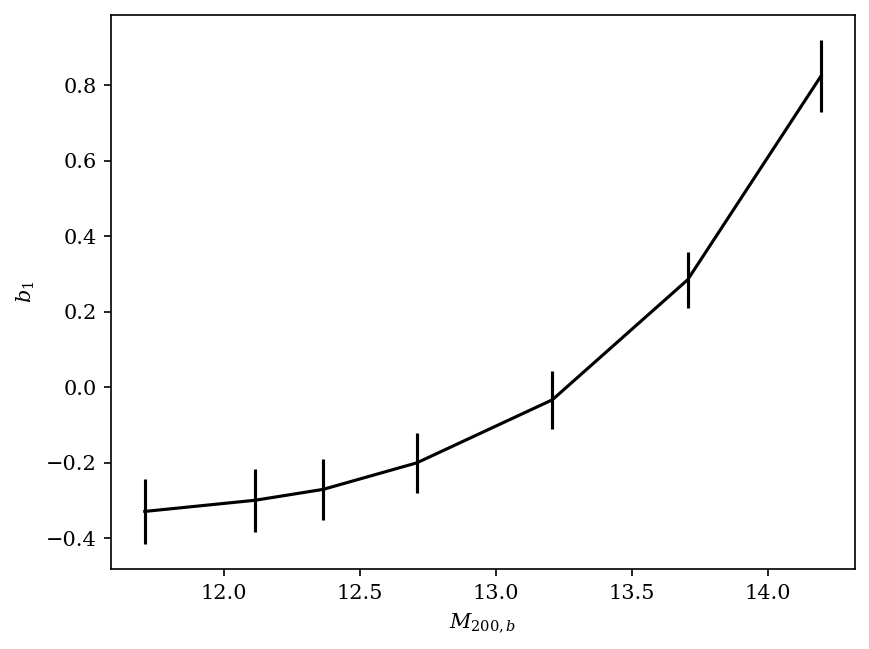

In [12]:
fig, ax = plt.subplots(dpi=150)

ax.set_xscale("linear")

# ax.scatter(m200b_halo, b_halo[:,0], s=0.01)
ax.errorbar(m200b_weight, b_halo_m200b[:,0], 10*np.sqrt(bcov_halo_m200b[:,0,0]), color='k')
ax.set_xlabel("$M_{200,b}$")
ax.set_ylabel("$b_1$")